
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_13_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar imágenes binarias y recuperar una imagen original a partir de una versión con ruido.


# Actividades

Para las imágenes dadas, construya un algoritmo que permita recuperar la imagen original a partir de una imagen perturbada.

Debe implementar funciones para:

1. Convertir una imagen binaria en un vector de estados.
2. Calcular la matriz de pesos de Hopfield.
3. Calcular el campo local que siente una neurona.
4. Actualizar el estado de una neurona.
5. Calcular la energía total de la red.
6. Aplicar ruido a una imagen.
7. Recuperar la imagen mediante actualización asincrónica aleatoria.

---

# Modelo de Hopfield

La matriz de pesos se define mediante la regla de Hebb:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu \xi_j^\mu
$$

con:

$$
w_{ii}=0
$$

donde:

- $N$ es el número total de píxeles,
- $P$ es el número de patrones almacenados,
- $\xi^\mu$ es el patrón $\mu$-ésimo.

---

# Campo local

Para una neurona $i$, el campo local es:

$$
h_i=\sum_j w_{ij}s_j
$$

Este campo representa la influencia colectiva que todas las demás neuronas ejercen sobre la neurona $i$.

---

# Regla de actualización

La actualización determinista de Hopfield es:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

Si:

$$
h_i>0
$$

entonces:

$$
s_i=1
$$

Si:

$$
h_i<0
$$

entonces:

$$
s_i=-1
$$

---

# Energía de la red

La energía total del sistema se define como:

$$
E(s)=-\frac{1}{2}\sum_{ij}w_{ij}s_is_j
$$

o equivalentemente:

$$
E(s)=-\frac{1}{2}s^TWs
$$

El proceso de recuperación debe tender a disminuir la energía.

---

# Algoritmo sugerido

Dada una imagen con ruido:

1. Seleccione aleatoriamente un píxel $i$.
2. Calcule el campo local:

$$
h_i=\sum_j w_{ij}s_j
$$

3. Actualice el estado del píxel:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

4. Calcule la nueva energía del sistema:

$$
E(s)=-\frac{1}{2}s^TWs
$$

5. Visite otro píxel aleatoriamente.
6. Repita el proceso hasta que:
   - la imagen deje de cambiar,
   - la energía se estabilice,
   - o se alcance un número máximo de iteraciones.


# Comentario importante

La actualización debe ser preferiblemente **asincrónica y aleatoria**, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.

---

# Preguntas guía

1. ¿La energía disminuye durante la recuperación?
2. ¿La red recupera exactamente la imagen original?
3. ¿Qué ocurre si aumenta el nivel de ruido?
4. ¿Qué pasa si se almacenan varias imágenes?
5. ¿Aparecen estados espurios?
6. ¿La recuperación depende del orden en que se actualizan los píxeles?
7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

---

# Capacidad de memoria

La capacidad aproximada de una red de Hopfield clásica es:

$$
P_c \approx 0.138N
$$

donde:

- $P_c$ es el número máximo de patrones recuperables,
- $N$ es el número total de neuronas.

Cuando el número de patrones almacenados supera este valor, aparecen errores y estados espurios.




In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac=0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido

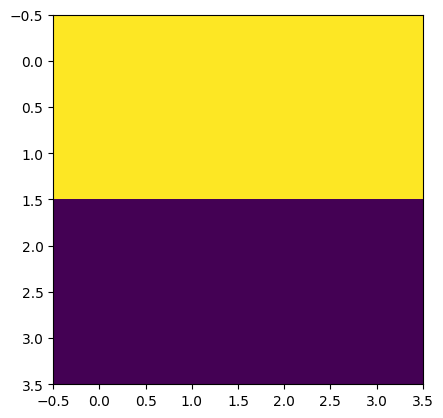

In [3]:
h, v, d = patrones_balanceados(4, 4)
plt.imshow(h)

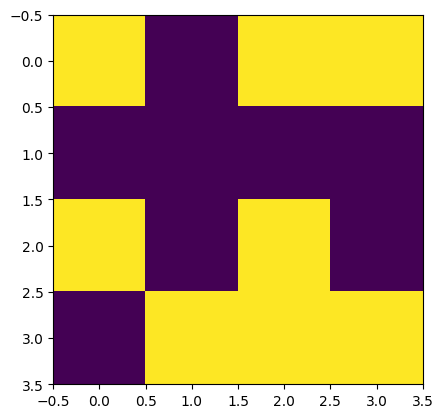

In [4]:
s_ruido = agregar_ruido(np.concat(d), frac=0.25, seed=10)
plt.imshow(np.reshape(s_ruido, (4,4)))

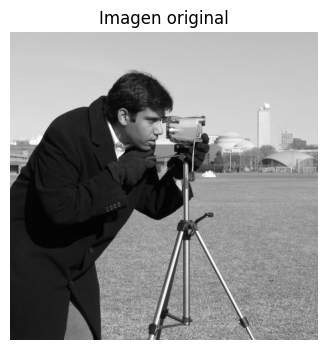

In [5]:
from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

img = data.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

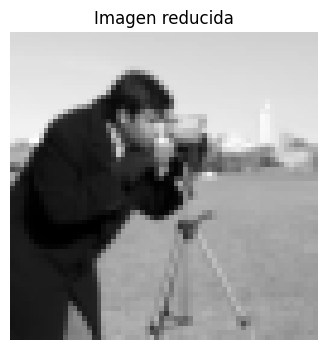

In [6]:
# ============================================================
# Reducir imagen
# ============================================================

n = 64
m = 64

img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4,4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida")
plt.axis("off")
plt.show()

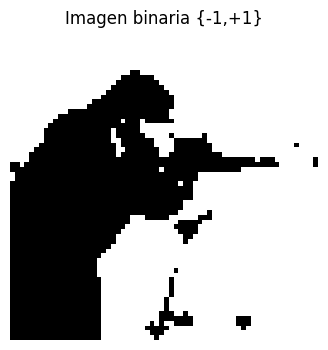

In [7]:
# ============================================================
# Binarización
# ============================================================

threshold = img_small.mean()

img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4,4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1,+1}")
plt.axis("off")
plt.show()

In [8]:
img_bin

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       ...,
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1]], shape=(64, 64))

In [9]:
# ============================================================
# Ruido
# ============================================================

def agregar_ruido(s, frac=0.30, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido


frac_ruido = 0.30

s_ruido = agregar_ruido(np.concat(img_bin), frac=frac_ruido, seed=123)


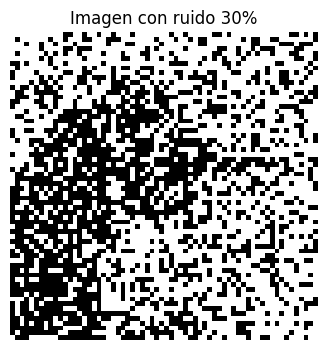

In [10]:
plt.figure(figsize=(4,4))
plt.imshow(s_ruido.reshape(n, m), cmap="gray")
plt.title(f"Imagen con ruido {frac_ruido*100:.0f}%")
plt.axis("off")
plt.show()

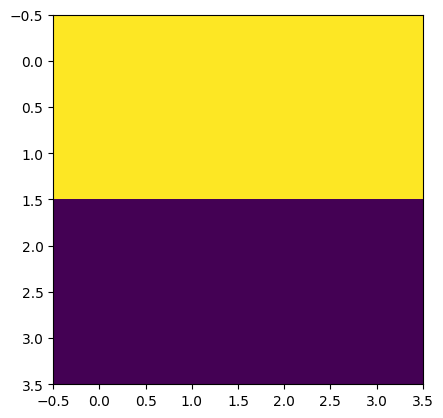

In [11]:
n=4
m=4
N=n*m
h, v, d = patrones_balanceados(n, m)
plt.imshow(h)

psi = np.zeros((3,N))
psi[0] = np.concat(h)
psi[1] = np.concat(v)
psi[2] = np.concat(d)

In [19]:
def calcular_pesos(psi, N):
    W = np.zeros((N, N))
    for i in range(0,N):
        for j in range(0,N):
            if i != j:
                W[i,j] = sum(p[i]*p[j] for p in psi)
    return W

W = calcular_pesos(psi, N)

def campo(W, s):
    return W @ s

def energia(campo,s):
    return -0.5 * s.T@campo


"""
W = calcular_pesos([h,v,d])
ch = campo(W, h.flatten())
cv = campo(W, v.flatten())
cd = campo(W, d.flatten())

eh = energia(ch, h.flatten())
ev = energia(cv, v.flatten())
ed = energia(cd, d.flatten())

print(eh,ev,ed)
"""

W.shape

(16, 16)

In [13]:
# Extraido de https://medium.com/@tommasocaputi85/hopfield-network-python-implementation-05a9f2f337de
# Quiero comparar este algoritmo con el que hizo el profesor en clase.
import numpy as np # for numerical operations 
import matplotlib.pyplot as plt # for displaying images(array) 
from PIL import Image # for image processing

In [48]:
def load_img(path, side): # Load and process images into a binary array, where pixels are represented as 1 or -1
    img = Image.open(path)
    img = img.resize((side, side))
    img = img.convert('1')
    img = 2 * np.array(img, int) - 1
    return img.flatten()

def show_array(img_array): # Visualize images(array)
    side = int(np.sqrt(img_array.shape[0]))
    img_array = img_array.reshape((side, side))
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

def show_multiple_arrays(img_arrays):
    fig = plt.figure(figsize=(3, 3))
    for i in range(len(img_arrays)):
        side = int(np.sqrt(img_arrays[i].shape[0]))
        plt.subplot(1, len(img_arrays), i+1)
        plt.imshow(img_arrays[i].reshape((side, side)))
        plt.axis('off')
    plt.show()

def modify_img(img, n_flip):
    indices = np.random.choice(len(img), n_flip, replace=False)
    noisy = img.copy()
    noisy[indices] *= -1
    return noisy

In [49]:
def calculate_w(img): # Create a weight matrix using the Hebbian learning rule based on the outer product of the image vector.
    '''
    w = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i != j:
                w[i,j] = img[i] * img[j]
    '''
    return np.outer(img, img)

# reconstruct image
def reconstructed_image(n, w, state): # Use the weight matrix to reconstruct an image from a modified or noisy version
    for i in range(n):
        sum = 0
        for j in range(n):
            sum += w[i,j] * state[j]
        state[i] = 1 if sum > 0 else -1
    return state
    # return np.dot(w, state)

memorized images:


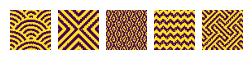

(2500,)
init state:


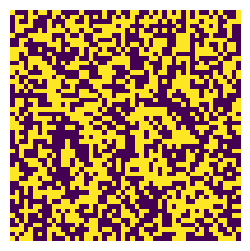

reconstructed image:


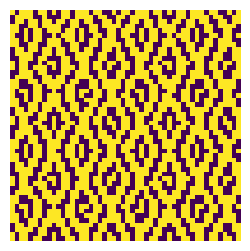

In [50]:
#multile patterns memory
side = 50
n = side * side #number of neurons(pixels)

#memory images
imgs=[]
for i in range(1,6): #memorize images from 1 to x-1
  imgs.append(load_img(f'p{i}.jpeg', side))

print('memorized images:')
show_multiple_arrays(imgs)

print(imgs[0].shape)
#weights matrix
w = np.zeros((n,n))
for p in range(len(imgs)):
  w+=calculate_w(imgs[p])

#set inital state
state = modify_img(load_img('p2.jpeg', side), n // 4) #modified image (25% random pixels flipped)
state = np.random.choice([-1,1], size=n) #random pixels
print('init state:')
show_array(state)

#reconstruct image
state = reconstructed_image(n, w, state)
print('reconstructed image:')
show_array(state)

Parece ser que el estado inicial es demasiado aleatorio y a la red le cuesta decidir a cual estado evolucionar. Además, el algoritmo del Blog de Medium no aplica la actualización de forma *ASÍNCRONA* e *ITERATIVA*.

Vamos a intentar mejorar esta implementación, haciendo que los valores se actualicen de forma iterativa y aleatoria hasta que suceda alguna de las dos condiciones de parada:

1. La energia tiende a cero bajo un umbral epsilon
2. Se supera el máximo de iteraciones especificado: max_iter

In [51]:
def hopfield_energy(w, state):
    return -0.5 * state @ w @ state


def reconstruct_async(n, w, state, max_iter=200, epsilon=1e-3):
    state = state.copy()
    energy = hopfield_energy(w, state)
    delta_e = float('inf')

    for iteration in range(max_iter):
        # Asynchronous: random neuron order per sweep
        indices = np.random.permutation(n)
        for i in indices:
            h_i = w[i] @ state
            state[i] = 1 if h_i >= 0 else -1

        new_energy = hopfield_energy(w, state)
        delta_e = abs(new_energy - energy)
        energy = new_energy

        # Stopping condition 1: energy change below epsilon
        if delta_e < epsilon:
            print(f"Converged at iteration {iteration + 1} | ΔE = {delta_e:.2e}")
            return state

    # Stopping condition 2: max iterations reached
    print(f"Stopped at max_iter={max_iter} | last ΔE = {delta_e:.2e}")
    return state

Converged at iteration 2 | ΔE = 0.00e+00


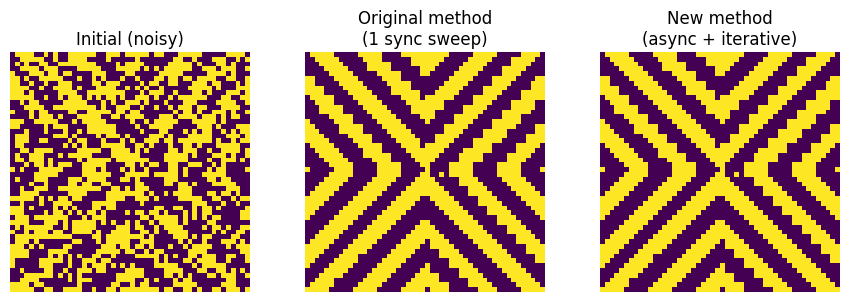

In [52]:
# Comparison: synchronous single-sweep (original) vs async iterative (new)

# 25% of pixels randomly flipped
noisy_state = modify_img(load_img('p2.jpeg', side), n // 4)

# --- Original method (1 synchronous sweep) ---
state_sync = reconstructed_image(n, w, noisy_state.copy())

# --- New method (async + iterative) ---
state_async = reconstruct_async(n, w, noisy_state, max_iter=200, epsilon=1e-3)

# Display
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
titles = ['Initial (noisy)', 'Original method\n(1 sync sweep)', 'New method\n(async + iterative)']
states = [noisy_state, state_sync, state_async]

for ax, title, s in zip(axes, titles, states):
    ax.imshow(s.reshape(side, side))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Como bien me mencionó el profesor, la diferencia no es notable y la convergencia sucede casi al instante debido a las condiciones de frontera periódicas de estos patrones. La optimizacion de asincronía e iteratividad se debe notar en imagenes de otra naturaleza.